In [12]:
import pandas as pd

# Load the Data

In [13]:
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

# --- ADD THIS FEATURE ENGINEERING BLOCK ---
# Calculate financial ratios (Standard industry practice for credit risk)
df['payment_to_income'] = df['loan_amt_outstanding'] / df['income']
df['debt_to_income'] = df['total_debt_outstanding'] / df['income']

# Select the updated feature set
features = [
    'credit_lines_outstanding', 
    'debt_to_income', 
    'payment_to_income', 
    'years_employed', 
    'fico_score'
]

# Separate features (X) and target (y)
X = df[features]
y = df['default']


# Preprocess the Data

In [14]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scaling is crucial for Logistic Regression to perform optimally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Model Training & Comparison

Logistic Regression - Accuracy: 0.9985 | AUC-ROC: 1.0000
Gradient Boosting   - Accuracy: 0.9980 | AUC-ROC: 0.9999



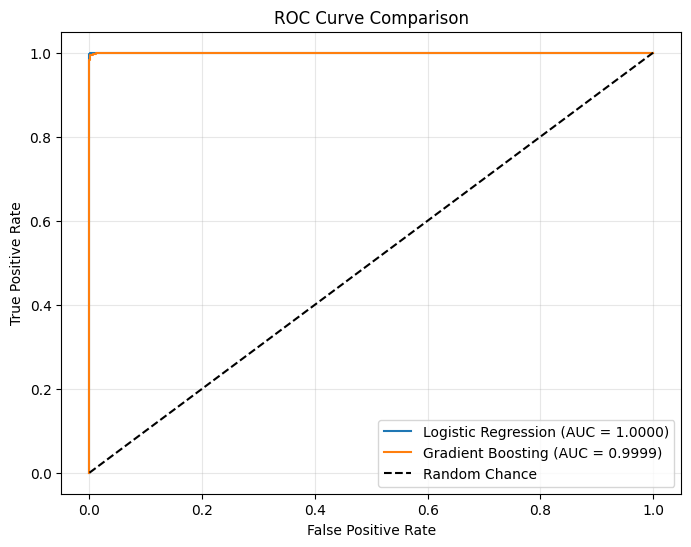

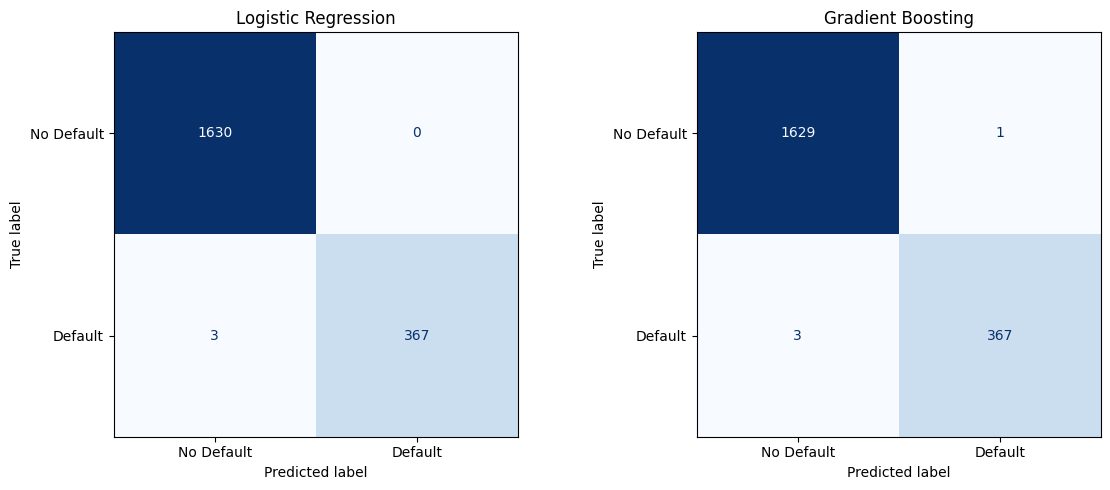

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Model A: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

print(f"Logistic Regression - Accuracy: {accuracy_score(y_test, lr_preds):.4f} | AUC-ROC: {roc_auc_score(y_test, lr_probs):.4f}")

# Model B: Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_probs = gb_model.predict_proba(X_test)[:, 1]

print(f"Gradient Boosting   - Accuracy: {accuracy_score(y_test, gb_preds):.4f} | AUC-ROC: {roc_auc_score(y_test, gb_probs):.4f}\n")


# ==========================================
# NEW ADDITIONS: VISUALIZATIONS
# ==========================================

# 1. Plot Combined ROC Curve
# Calculate False Positive Rates (FPR) and True Positive Rates (TPR)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.4f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, gb_probs):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance') # Diagonal dotted line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2. Plot Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LR Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_preds)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Default', 'Default'])
disp_lr.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression')

# GB Confusion Matrix
cm_gb = confusion_matrix(y_test, gb_preds)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=['No Default', 'Default'])
disp_gb.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Gradient Boosting')

plt.tight_layout()
plt.show()

# Expected Loss Function Definition

In [16]:
def calculate_expected_loss(loan_properties, model, fitted_scaler, recovery_rate=0.10):
    """
    Takes in dictionary of raw loan properties, engineers the required features, 
    and returns the Expected Loss.
    """
    # 1. Convert dictionary to DataFrame
    df_input = pd.DataFrame([loan_properties])
    
    # 2. FEATURE ENGINEERING (Calculate the ratios for the new borrower)
    df_input['payment_to_income'] = df_input['loan_amt_outstanding'] / df_input['income']
    df_input['debt_to_income'] = df_input['total_debt_outstanding'] / df_input['income']
    
    # 3. Ensure feature order exactly matches the training data!
    expected_features = [
        'credit_lines_outstanding', 
        'debt_to_income', 
        'payment_to_income', 
        'years_employed', 
        'fico_score'
    ]
    df_input = df_input[expected_features]
    
    # 4. Scale the input data using the fitted scaler
    scaled_input = fitted_scaler.transform(df_input)
    
    # 5. Calculate components
    pd_estimate = model.predict_proba(scaled_input)[0][1]     # Probability of Default
    ead = loan_properties['loan_amt_outstanding']             # Exposure at Default
    lgd = 1.0 - recovery_rate                                 # Loss Given Default
    
    # 6. Calculate final Expected Loss
    expected_loss = pd_estimate * ead * lgd
    
    return {
        "Probability of Default": f"{pd_estimate:.2%}",
        "Expected Loss ($)": round(expected_loss, 2)
    }



In [18]:
# ==========================================
# EXAMPLE USAGE (This will now run perfectly)
# ==========================================
hypothetical_loan = {
    'credit_lines_outstanding': 4,
    'loan_amt_outstanding': 15000.00,
    'total_debt_outstanding': 35000.00,
    'income': 55000.00,
    'years_employed': 3,
    'fico_score': 610
}

result = calculate_expected_loss(hypothetical_loan, lr_model, scaler, recovery_rate=0.10)

print("--- Expected Loss Output ---")
print(f"Loan Properties: {hypothetical_loan}")
print(f"Result: {result}")

--- Expected Loss Output ---
Loan Properties: {'credit_lines_outstanding': 4, 'loan_amt_outstanding': 15000.0, 'total_debt_outstanding': 35000.0, 'income': 55000.0, 'years_employed': 3, 'fico_score': 610}
Result: {'Probability of Default': '100.00%', 'Expected Loss ($)': 13500.0}
